# 完整實驗：重採樣 × 特徵選擇 綜合比較
## 🔬 2×3 網格實驗設計

### 實驗因子：
- **重採樣策略** (2種):
  - ENN only
  - ENN + SMOTE

- **特徵選擇策略** (3種):
  - A: Mean Threshold
  - B: Cumulative 95%
  - C: L1 Regularization

### 實驗組合 (共6組):
1. ENN + Mean Threshold
2. ENN + Cumulative 95%
3. ENN + L1 Regularization
4. ENN+SMOTE + Mean Threshold
5. ENN+SMOTE + Cumulative 95%
6. ENN+SMOTE + L1 Regularization

In [1]:
!pip install imbalanced-learn xgboost scikit-learn pandas numpy seaborn sentence-transformers -q


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import classification_report, f1_score, confusion_matrix

from sentence_transformers import SentenceTransformer

from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] # 繁體使用微軟正黑體，或用 SimHei (黑體)
plt.rcParams['axes.unicode_minus'] = False  # 解決負號顯示問題
print("✅ 套件載入完成")

✅ 套件載入完成


## 📂 Phase 0-3: 資料前處理

In [3]:
# 載入資料
df_train_full = pd.read_csv('data/boy or girl 2025 train_missingValue.csv')
df_test = pd.read_csv('data/boy or girl 2025 test no ans_missingValue.csv')

# Train/Valid Split
X_full = df_train_full.drop(columns=['gender'])
y_full = df_train_full['gender']
X_train, X_valid, y_train, y_valid = train_test_split(X_full, y_full, test_size=0.2, random_state=42, stratify=y_full)

print(f"Train: {X_train.shape}, Valid: {X_valid.shape}")

Train: (338, 10), Valid: (85, 10)


In [4]:
# 特徵工程函數
def is_repeated_or_symbol(s):
    if pd.isna(s) or s == '' or s == 'nan': return False
    if re.fullmatch(r'[^A-Za-z0-9\u4e00-\u9fff]+', s): return True
    if re.fullmatch(r'(.)\1{3,}', s): return True
    return False

def build_features(df):
    df = df.copy()
    if 'phone_os' in df.columns:
        is_missing = df['phone_os'].isna()
        df['phone_os_clean'] = df['phone_os'].astype(str).str.strip().str.lower().replace({'iphone': 'apple', 'ios': 'apple', 'android': 'android'})
        valid_os = {'android', 'apple'}
        df['is_phone_os_invalid'] = np.where(df['phone_os'].notna() & ~df['phone_os_clean'].isin(valid_os), 1, 0)
        df.loc[df['is_phone_os_invalid'] == 1, 'phone_os_clean'] = 'Unknown'
        df.loc[is_missing, 'phone_os_clean'] = 'Unknown' 
        df.drop(columns=['is_phone_os_invalid'], inplace=True, errors='ignore')
        df.drop(columns=['phone_os'], inplace=True, errors='ignore')
    if 'weight' in df.columns:
        df['is_weight_missing'] = df['weight'].isna().astype(int)
        df['is_weight_outlier'] = np.where(df['weight'].notna() & ((df['weight'] < 30) | (df['weight'] > 1000)), 1, 0)
        df['weight'] = df['weight'].clip(lower=40, upper=120)
    if 'height' in df.columns:
        df['is_height_missing'] = df['height'].isna().astype(int)
        df['is_height_outlier'] = np.where(df['height'].notna() & ((df['height'] < 130) | (df['height'] > 220)), 1, 0)
        df['height'] = df['height'].clip(lower=140, upper=200)
    if 'iq' in df.columns:
        df['is_iq_missing'] = df['iq'].isna().astype(int)
        df['is_iq_outlier'] = np.where(df['iq'].notna() & ((df['iq'] < 100) | (df['iq'] > 140)), 1, 0)
        df['iq'] = df['iq'].clip(lower=100, upper=140)
    if 'fb_friends' in df.columns:
        df['is_fb_friends_missing'] = df['fb_friends'].isna().astype(int)
        df['is_fb_friends_outlier'] = np.where(df['fb_friends'].notna() & ((df['fb_friends'] < 0) | (df['fb_friends'] > 2000)), 1, 0)
        df['fb_friends'] = df['fb_friends'].clip(lower=0, upper=2000)
    if 'yt' in df.columns:
        df['yt'] = pd.to_numeric(df['yt'], errors='coerce')
        df['is_yt_missing'] = df['yt'].isna().astype(int)
        df['is_yt_outlier'] = np.where(df['yt'].notna() & ((df['yt'] < 0) | (df['yt'] > 24)), 1, df.get('is_yt_invalid', 0))
        df['yt'] = df['yt'].clip(lower=0, upper=24)
    if 'star_sign' in df.columns:
        # 定義標準中文星座名稱
        valid_stars = {'白羊座', '金牛座', '雙子座', '巨蟹座', '獅子座', '處女座',
                       '天秤座', '天蠍座', '射手座', '摩羯座', '水瓶座', '雙魚座'}

        # 同名星座映射字典 (將所有同名、英文名稱映射到標準中文名稱)
        star_sign_mapping = {
            # 白羊座別名
            '白羊座': '白羊座',
            '牡羊座': '白羊座',
            'aries': '白羊座',
            # 金牛座
            '金牛座': '金牛座',
            'taurus': '金牛座',
            # 雙子座別名
            '雙子座': '雙子座',
            '双子座': '雙子座',
            'gemini': '雙子座',
            # 巨蟹座
            '巨蟹座': '巨蟹座',
            'cancer': '巨蟹座',
            # 獅子座別名
            '獅子座': '獅子座',
            '狮子座': '獅子座',
            'leo': '獅子座',
            # 處女座別名
            '處女座': '處女座',
            '处女座': '處女座',
            '室女座': '處女座',
            'virgo': '處女座',
            # 天秤座別名
            '天秤座': '天秤座',
            '天平座': '天秤座',
            'libra': '天秤座',
            # 天蠍座別名
            '天蠍座': '天蠍座',
            '天蝎座': '天蠍座',
            'scorpio': '天蠍座',
            # 射手座別名
            '射手座': '射手座',
            '人馬座': '射手座',
            '人马座': '射手座',
            'sagittarius': '射手座',
            # 摩羯座別名
            '摩羯座': '摩羯座',
            '魔羯座': '摩羯座',
            '山羊座': '摩羯座',
            'capricorn': '摩羯座',
            # 水瓶座別名
            '水瓶座': '水瓶座',
            '宝瓶座': '水瓶座',
            '寶瓶座': '水瓶座',
            'aquarius': '水瓶座',
            # 雙魚座別名
            '雙魚座': '雙魚座',
            '双鱼座': '雙魚座',
            'pisces': '雙魚座'
        }

        # 清理並標準化星座名稱
        df['star_sign_clean'] = df['star_sign'].astype(str).str.strip().str.lower()

        # 映射到標準中文名稱
        df['star_sign_clean'] = df['star_sign_clean'].map(star_sign_mapping)

        # 標記無效星座
        df['is_star_sign_invalid'] = np.where(df['star_sign'].notna() & df['star_sign_clean'].isna(), 1, 0)
        df.loc[df['is_star_sign_invalid'] == 1, 'star_sign_clean'] = 'Unknown'
        df.drop(columns=['is_star_sign_invalid'], inplace=True, errors='ignore')
        df.drop(columns=['star_sign'], inplace=True, errors='ignore')
    if 'self_intro' in df.columns:
        df['intro_char_length'] = df['self_intro'].fillna('').astype(str).str.len()
        df['intro_word_count'] = df['self_intro'].fillna('').astype(str).str.split().apply(len)
        df['intro_is_all_lower'] = df['self_intro'].fillna('').astype(str).apply(lambda s: s.islower() if s else False).astype(int)
        df['intro_is_all_upper'] = df['self_intro'].fillna('').astype(str).apply(lambda s: s.isupper() if s else False).astype(int)
        df['is_intro_anomalous'] = 0
        df.loc[df['intro_char_length'] == 0, 'is_intro_anomalous'] = 1
        df.loc[df['intro_char_length'] > 500, 'is_intro_anomalous'] = 1
        df.loc[df['self_intro'].fillna('').astype(str).apply(is_repeated_or_symbol), 'is_intro_anomalous'] = 1
        df.loc[df['is_intro_anomalous'] == 1, 'self_intro'] = np.nan
        df.drop(columns=['intro_char_length'], inplace=True, errors='ignore')
        df.drop(columns=['self_intro'], inplace=True, errors='ignore')
    return df

X_train_clean = build_features(X_train)
X_valid_clean = build_features(X_valid)
X_test_clean = build_features(df_test)

print("✅ Phase 0-2 完成（含 MiniLM nlp_boy_prob 特徵）")

✅ Phase 0-2 完成（含 MiniLM nlp_boy_prob 特徵）


In [5]:
# Phase 3: MissForest (train-only fit，避免資料洩漏)
num_cols = [c for c in ['height', 'weight', 'iq', 'fb_friends', 'yt', 'sleepiness'] if c in X_train_clean.columns]
cat_cols = [c for c in ['phone_os_clean', 'star_sign_clean'] if c in X_train_clean.columns]

# 使用 train 的統計量填補類別特徵（避免 leakage）
for c in cat_cols:
    mode_val = X_train_clean[c].mode(dropna=True)
    fill_val = mode_val.iloc[0] if len(mode_val) > 0 else 'Unknown'
    X_train_clean[c] = X_train_clean[c].fillna(fill_val)
    X_valid_clean[c] = X_valid_clean[c].fillna(fill_val)
    X_test_clean[c] = X_test_clean[c].fillna(fill_val)

# MissForest: IterativeImputer + RandomForestRegressor
rf_estimator = RandomForestRegressor(
    n_estimators=80,
    max_depth=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
miss_forest = IterativeImputer(
    estimator=rf_estimator,
    random_state=42,
    max_iter=12,
    initial_strategy='mean'
)

if len(num_cols) > 0:
    X_train_clean[num_cols] = miss_forest.fit_transform(X_train_clean[num_cols])
    X_valid_clean[num_cols] = miss_forest.transform(X_valid_clean[num_cols])
    X_test_clean[num_cols] = miss_forest.transform(X_test_clean[num_cols])

print("✅ Phase 3 完成 (MissForest + train-only 統計填補)")

✅ Phase 3 完成 (MissForest + train-only 統計填補)


In [6]:
# One-Hot Encoding
X_train_enc = pd.get_dummies(X_train_clean, columns=cat_cols, dummy_na=True)
X_valid_enc = pd.get_dummies(X_valid_clean, columns=cat_cols, dummy_na=True)
X_test_enc = pd.get_dummies(X_test_clean, columns=cat_cols, dummy_na=True)

X_train_enc, X_valid_enc = X_train_enc.align(X_valid_enc, join='left', axis=1, fill_value=0)
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)

# ============================================================
# 合併 phone_os_clean 的 Unknown 和 nan 列
# ============================================================
phone_os_cols = [col for col in X_train_enc.columns if col.startswith('phone_os_clean_')]
print(f"\n原始 phone_os_clean 欄位: {phone_os_cols}")

# 合併 Unknown 和 nan 為單一的 "未知" 欄位
for df in [X_train_enc, X_valid_enc, X_test_enc]:
    if 'phone_os_clean_Unknown' in df.columns and 'phone_os_clean_nan' in df.columns:
        # 創建合併後的欄位 (只要其中一個是 1，結果就是 1)
        df['phone_os_clean_Unknown'] = df[['phone_os_clean_Unknown', 'phone_os_clean_nan']].max(axis=1)
        # 刪除 nan 欄位
        df.drop(columns=['phone_os_clean_nan'], inplace=True)
    elif 'phone_os_clean_nan' in df.columns:
        # 如果只有 nan，重命名為 Unknown
        df.rename(columns={'phone_os_clean_nan': 'phone_os_clean_Unknown'}, inplace=True)

# 對齊三個資料集（確保欄位一致）
X_train_enc, X_valid_enc = X_train_enc.align(X_valid_enc, join='left', axis=1, fill_value=0)
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)

phone_os_cols_after = [col for col in X_train_enc.columns if col.startswith('phone_os_clean_')]
print(f"合併後 phone_os_clean 欄位: {phone_os_cols_after}\n")

# ============================================================
# 移除 id 欄位
# ============================================================
test_ids = X_test_enc.pop('id') if 'id' in X_test_enc.columns else None
if 'id' in X_train_enc.columns:
    X_train_enc.pop('id')
if 'id' in X_valid_enc.columns:
    X_valid_enc.pop('id')

# Phase 3 合理性檢查：確認編碼後沒有遺漏缺失值
remaining_train_na = int(X_train_enc.isna().sum().sum())
remaining_valid_na = int(X_valid_enc.isna().sum().sum())
remaining_test_na = int(X_test_enc.isna().sum().sum())

if remaining_train_na > 0 or remaining_valid_na > 0 or remaining_test_na > 0:
    print("⚠️ 發現剩餘缺失值，啟用保底填補 (numeric=0, non-numeric='Unknown')")
    for df in [X_train_enc, X_valid_enc, X_test_enc]:
        num_cols_enc = df.select_dtypes(include=[np.number]).columns
        obj_cols_enc = df.select_dtypes(exclude=[np.number]).columns
        if len(num_cols_enc) > 0:
            df[num_cols_enc] = df[num_cols_enc].fillna(0)
        if len(obj_cols_enc) > 0:
            df[obj_cols_enc] = df[obj_cols_enc].fillna('Unknown')

print(f"✅ Encoding 完成，特徵數: {X_train_enc.shape[1]}")
print(f"缺失值檢查 -> train:{int(X_train_enc.isna().sum().sum())}, valid:{int(X_valid_enc.isna().sum().sum())}, test:{int(X_test_enc.isna().sum().sum())}")


原始 phone_os_clean 欄位: ['phone_os_clean_Unknown', 'phone_os_clean_android', 'phone_os_clean_apple', 'phone_os_clean_nan']
合併後 phone_os_clean 欄位: ['phone_os_clean_Unknown', 'phone_os_clean_android', 'phone_os_clean_apple']

✅ Encoding 完成，特徵數: 36
缺失值檢查 -> train:0, valid:0, test:0


## ⚖️ Phase 4: 準備兩組重採樣資料

In [7]:
print("="*70)
print("準備兩種重採樣策略的訓練集")
print("="*70)

# ===== 策略 1: ENN only =====
print("\n【重採樣 1】ENN only")
enn1 = EditedNearestNeighbours(n_neighbors=3)
X_train_enn, y_train_enn = enn1.fit_resample(X_train_enc, y_train)
print(f"樣本數: {X_train_enn.shape[0]}, 類別分布: {dict(pd.Series(y_train_enn).value_counts().sort_index())}")

# ===== 策略 2: ENN + SMOTE =====
print("\n【重採樣 2】ENN + SMOTE")
enn2 = EditedNearestNeighbours(n_neighbors=3)
X_after_enn, y_after_enn = enn2.fit_resample(X_train_enc, y_train)
smote = SMOTE(sampling_strategy=0.8, k_neighbors=3, random_state=42)
X_train_enn_smote, y_train_enn_smote = smote.fit_resample(X_after_enn, y_after_enn)
print(f"樣本數: {X_train_enn_smote.shape[0]}, 類別分布: {dict(pd.Series(y_train_enn_smote).value_counts().sort_index())}")

# 轉換標籤
labels_offset = y_train.min()
y_train_enn_xgb = y_train_enn - labels_offset
y_train_enn_smote_xgb = y_train_enn_smote - labels_offset
y_valid_xgb = y_valid - labels_offset

print("\n✅ 兩組重採樣資料準備完成")

準備兩種重採樣策略的訓練集

【重採樣 1】ENN only
樣本數: 245, 類別分布: {1: np.int64(160), 2: np.int64(85)}

【重採樣 2】ENN + SMOTE
樣本數: 288, 類別分布: {1: np.int64(160), 2: np.int64(128)}

✅ 兩組重採樣資料準備完成


## 🎯 Phase 5: 特徵重要性評估
使用 ENN+SMOTE 資料訓練 Random Forest

訓練 Random Forest 評估特徵重要性...


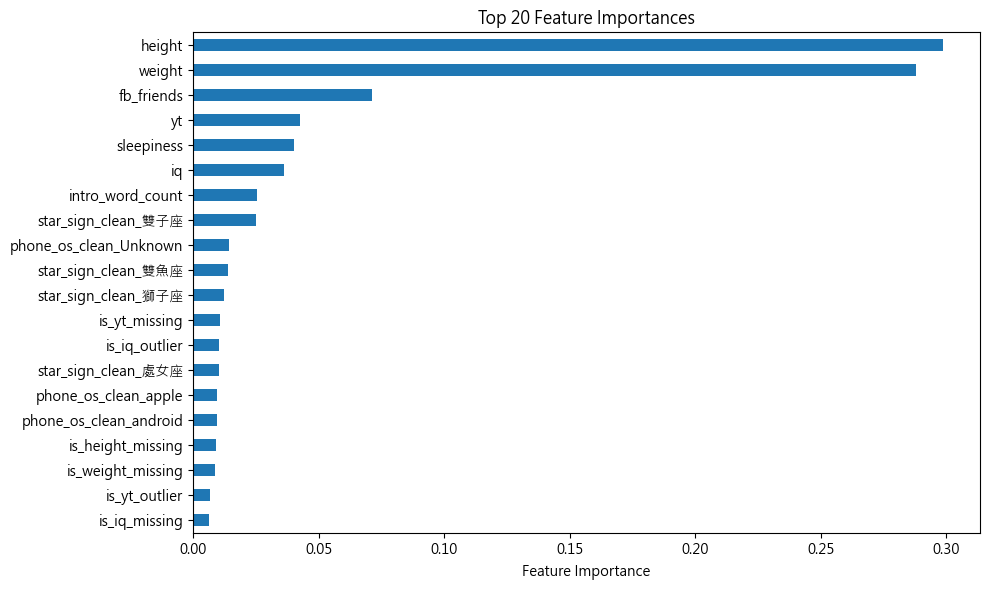


平均重要性: 0.0278


In [8]:
print("訓練 Random Forest 評估特徵重要性...")
fs_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
fs_model.fit(X_train_enn_smote, y_train_enn_smote)

feat_imp = pd.Series(fs_model.feature_importances_, index=X_train_enn_smote.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(20).plot(kind='barh')
plt.xlabel('Feature Importance')
plt.title('Top 20 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\n平均重要性: {feat_imp.mean():.4f}")

## 📊 相關係數矩陣分析 (Correlation Matrix)

在特徵選擇前，先分析特徵之間的相關性，幫助理解：

1. **特徵間的線性相關性** - 了解哪些特徵彼此相關
2. **潛在的多重共線性問題** - 識別高度相關的特徵對
3. **特徵與目標變數的關係** - 找出最有預測力的特徵

---

相關係數矩陣分析


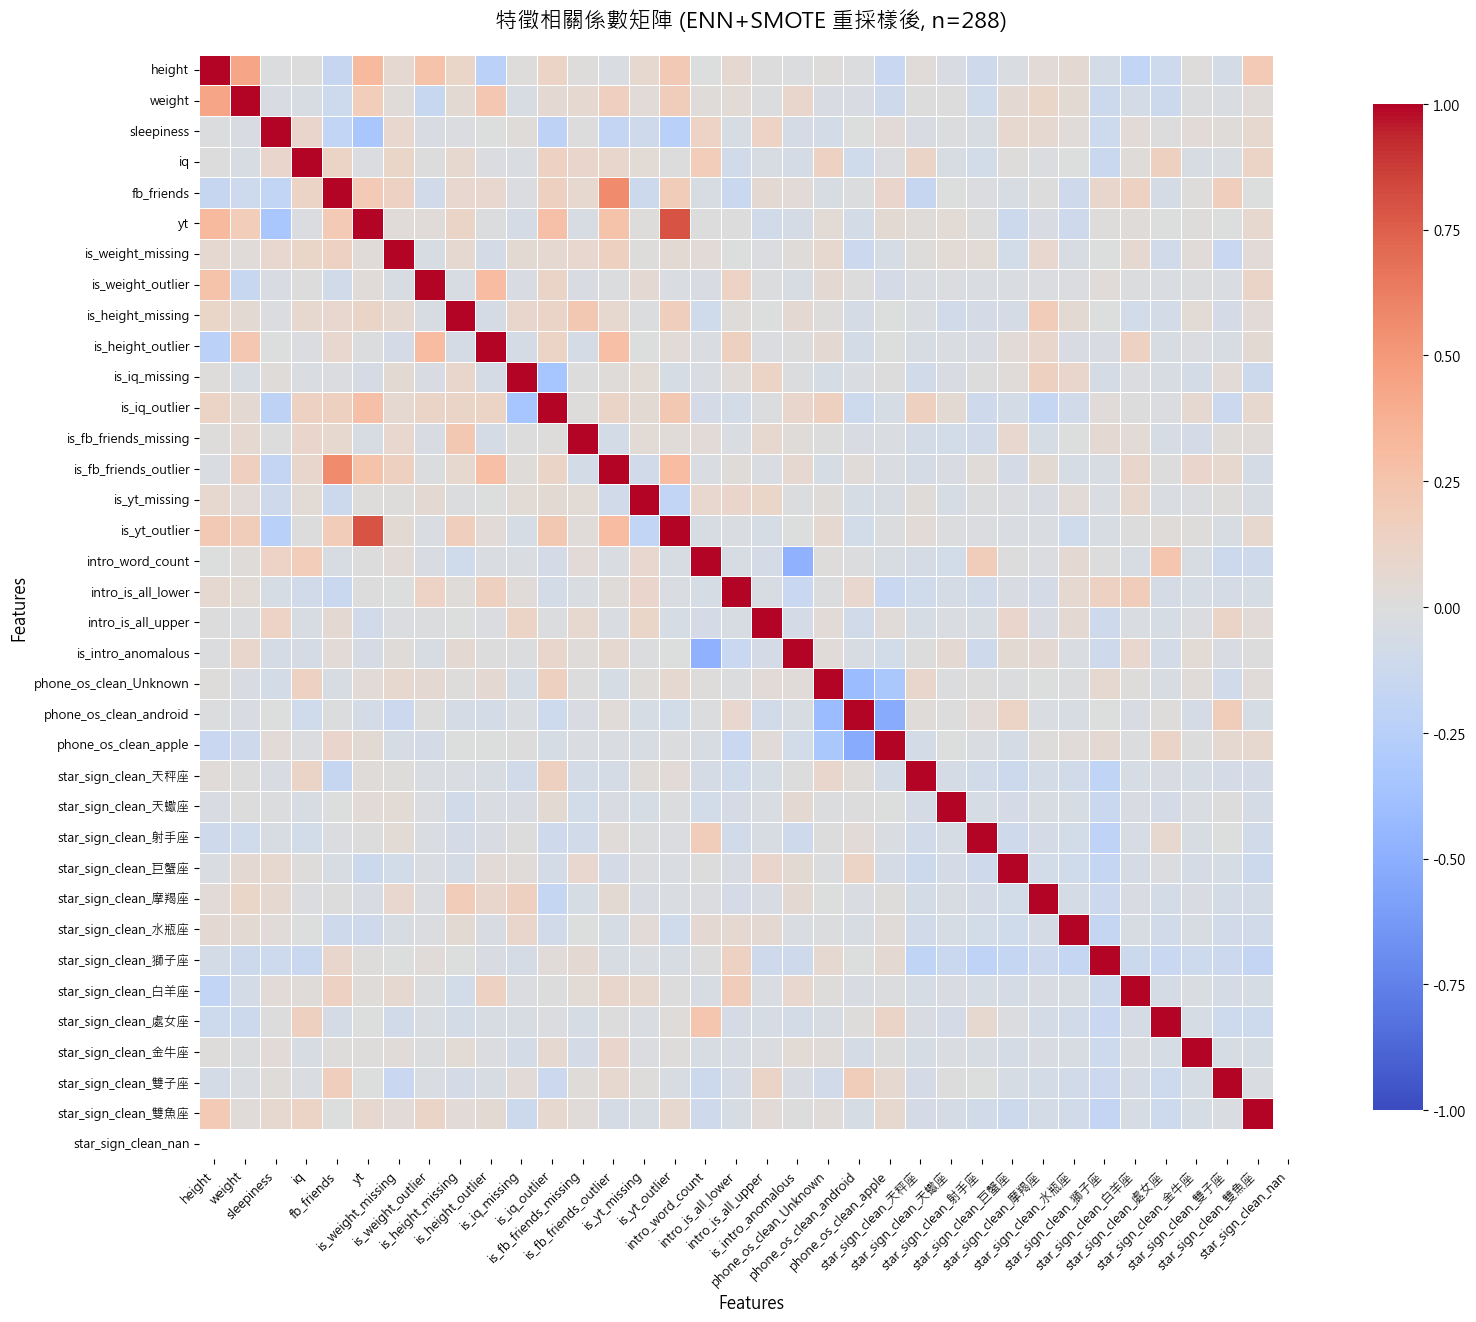


高度相關的特徵對 (|相關係數| > 0.8)
✅ 沒有發現高度相關 (|r| > 0.8) 的特徵對

數值特徵相關係數矩陣 (排除 One-Hot 編碼特徵)
數值特徵數量: 20
特徵列表: ['height', 'weight', 'sleepiness', 'iq', 'fb_friends', 'yt', 'is_weight_missing', 'is_weight_outlier', 'is_height_missing', 'is_height_outlier', 'is_iq_missing', 'is_iq_outlier', 'is_fb_friends_missing', 'is_fb_friends_outlier', 'is_yt_missing', 'is_yt_outlier', 'intro_word_count', 'intro_is_all_lower', 'intro_is_all_upper', 'is_intro_anomalous']



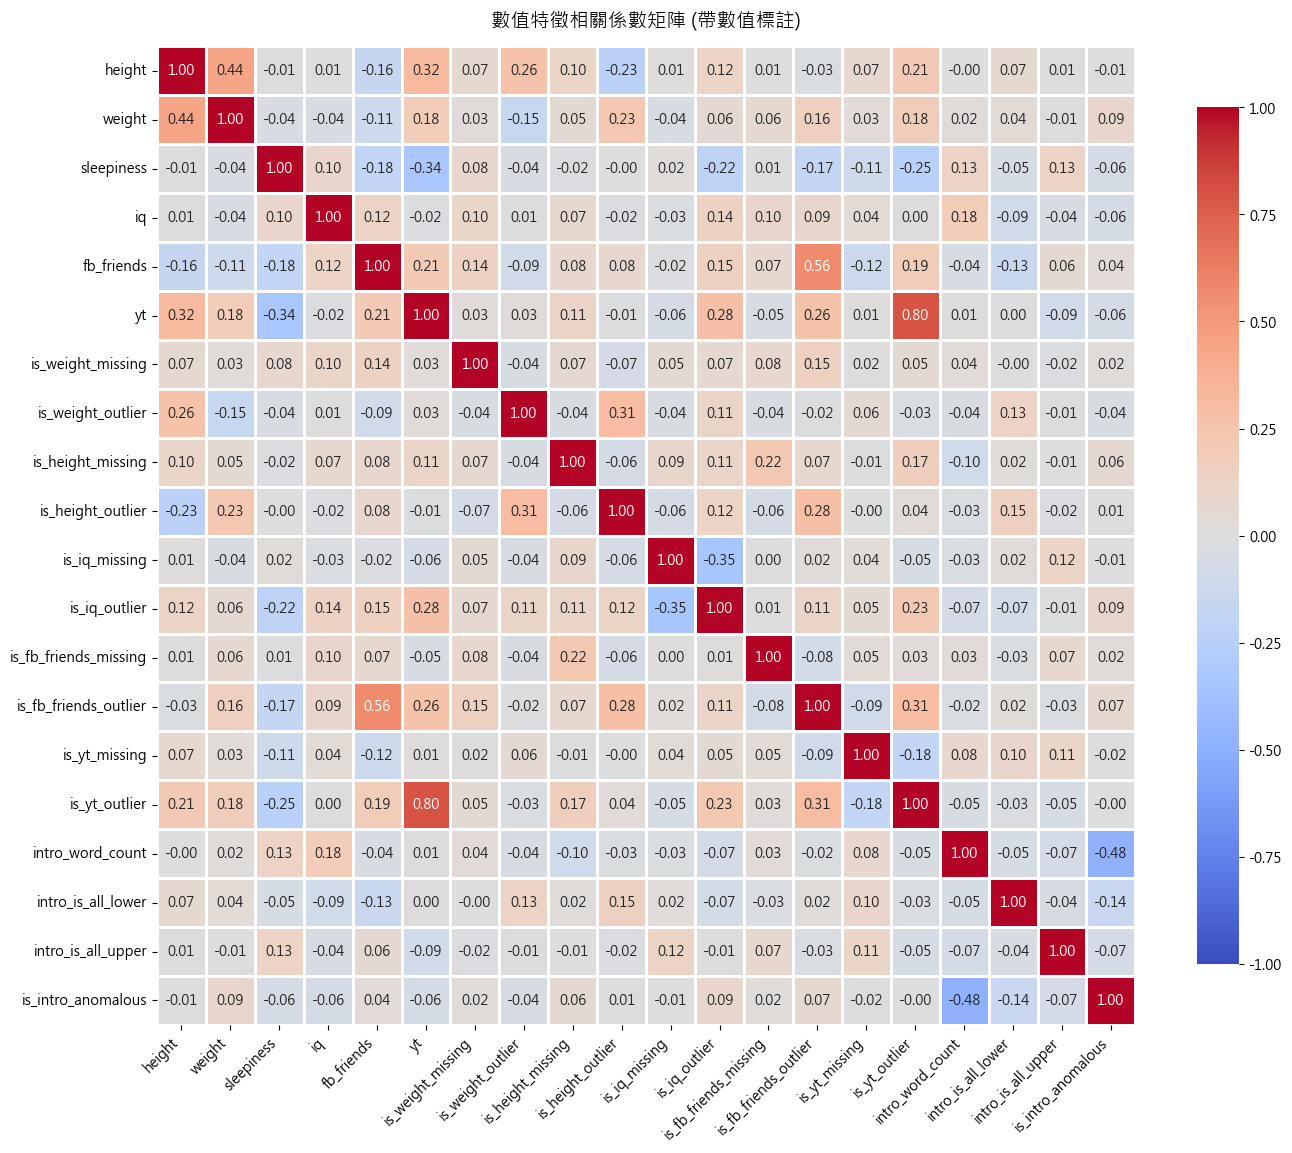


數值特徵相關係數統計:
  - 最大正相關: 0.795
  - 最大負相關: -0.483

特徵與目標變數 (gender) 的相關性

Top 15 與目標變數相關性最高的特徵:
                   特徵      相關係數      p-value 顯著性
               weight -0.603849 5.275813e-30 ***
               height -0.563487 1.564376e-25 ***
  star_sign_clean_雙子座  0.248968 1.917910e-05 ***
  star_sign_clean_處女座  0.198248 7.159588e-04 ***
           fb_friends  0.188165 1.336233e-03  **
 phone_os_clean_apple  0.156505 7.794376e-03  **
   intro_is_all_lower -0.143267 1.496101e-02   *
  star_sign_clean_水瓶座 -0.106898 7.007464e-02    
  star_sign_clean_摩羯座 -0.104699 7.607026e-02    
   is_intro_anomalous -0.100180 8.969721e-02    
                   iq  0.098376 9.565657e-02    
                   yt -0.096893 1.007907e-01    
  star_sign_clean_獅子座  0.093880 1.118838e-01    
is_fb_friends_outlier -0.080322 1.740270e-01    
  star_sign_clean_天秤座 -0.071919 2.236869e-01    


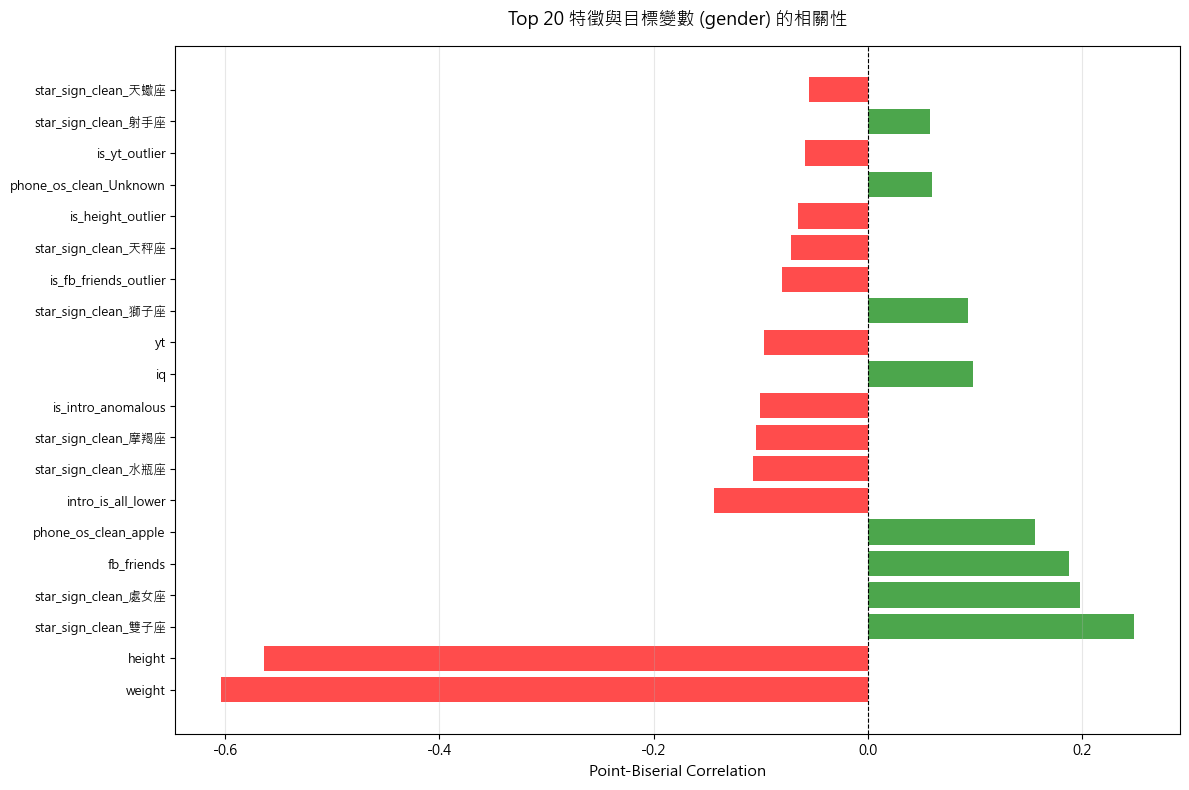


相關性分析完成


In [9]:
import seaborn as sns
from scipy.stats import pointbiserialr

# ============================================================
# 繪製相關係數矩陣
# ============================================================
print("="*70)
print("相關係數矩陣分析")
print("="*70)

# 選擇要分析的數據集 (使用 ENN+SMOTE 處理後的數據)
X_for_corr = X_train_enn_smote.copy()
y_for_corr = y_train_enn_smote.copy()

# 計算 Pearson 相關係數
corr_matrix = X_for_corr.corr()

# 設置圖形大小
fig, ax = plt.subplots(figsize=(16, 14))

# 繪製熱力圖
sns.heatmap(
    corr_matrix,
    annot=False,          # 不顯示數值（特徵太多會很擁擠）
    fmt='.2f',
    cmap='coolwarm',      # 藍色=負相關，紅色=正相關
    center=0,             # 0 為中心點
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    vmin=-1,
    vmax=1,
    ax=ax
)

plt.title(f'特徵相關係數矩陣 (ENN+SMOTE 重採樣後, n={X_for_corr.shape[0]})', fontsize=16, pad=20)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# ============================================================
# 尋找高度相關的特徵對 (|correlation| > 0.8)
# ============================================================
print("\n" + "="*70)
print("高度相關的特徵對 (|相關係數| > 0.8)")
print("="*70)

# 取得上三角矩陣（避免重複）
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# 找出高相關的特徵對
high_corr_pairs = []
for column in upper_triangle.columns:
    high_corr = upper_triangle[column][abs(upper_triangle[column]) > 0.8]
    for idx, value in high_corr.items():
        high_corr_pairs.append({
            '特徵1': idx,
            '特徵2': column,
            '相關係數': value
        })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(
        by='相關係數',
        key=abs,
        ascending=False
    )
    print(high_corr_df.to_string(index=False))
    print(f"\n⚠️  發現 {len(high_corr_pairs)} 對高度相關的特徵")
    print("建議：考慮移除其中一個特徵以降低多重共線性")
else:
    print("✅ 沒有發現高度相關 (|r| > 0.8) 的特徵對")

# ============================================================
# 只顯示數值特徵的相關係數（排除 One-Hot 編碼的類別特徵）
# ============================================================
print("\n" + "="*70)
print("數值特徵相關係數矩陣 (排除 One-Hot 編碼特徵)")
print("="*70)

# 識別數值特徵（排除 One-Hot 編碼的特徵）
numeric_features = [
    col for col in X_for_corr.columns
    if not any(cat_prefix in col for cat_prefix in ['phone_os_clean_', 'star_sign_clean_'])
]

print(f"數值特徵數量: {len(numeric_features)}")
print(f"特徵列表: {numeric_features}\n")

if len(numeric_features) > 1:
    # 計算數值特徵的相關係數
    numeric_corr = X_for_corr[numeric_features].corr()

    # 繪製數值特徵相關係數矩陣
    fig, ax = plt.subplots(figsize=(14, 12))

    sns.heatmap(
        numeric_corr,
        annot=True,           # 顯示數值
        fmt='.2f',
        cmap='coolwarm',
        center=0,
        square=True,
        linewidths=1,
        cbar_kws={"shrink": 0.8},
        vmin=-1,
        vmax=1,
        ax=ax
    )

    plt.title('數值特徵相關係數矩陣 (帶數值標註)', fontsize=14, pad=15)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()

    # 輸出相關係數統計
    print("\n數值特徵相關係數統計:")
    upper_tri_mask = np.triu(np.ones(numeric_corr.shape), k=1).astype(bool)
    print(f"  - 最大正相關: {numeric_corr.where(upper_tri_mask).max().max():.3f}")
    print(f"  - 最大負相關: {numeric_corr.where(upper_tri_mask).min().min():.3f}")

# ============================================================
# 特徵與目標變數的相關性（點二系列相關 Point-Biserial）
# ============================================================
print("\n" + "="*70)
print("特徵與目標變數 (gender) 的相關性")
print("="*70)

# 計算每個特徵與目標變數的相關性
feature_target_corr = []
for feature in X_for_corr.columns:
    # 使用 point-biserial correlation (適用於連續變數 vs 二元變數)
    corr, p_value = pointbiserialr(y_for_corr, X_for_corr[feature])
    feature_target_corr.append({
        '特徵': feature,
        '相關係數': corr,
        'p-value': p_value,
        '顯著性': '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else ''
    })

# 轉換為 DataFrame 並按絕對相關係數排序
corr_df = pd.DataFrame(feature_target_corr).sort_values(
    by='相關係數',
    key=abs,
    ascending=False
)

print("\nTop 15 與目標變數相關性最高的特徵:")
print(corr_df.head(15).to_string(index=False))

# 視覺化
fig, ax = plt.subplots(figsize=(12, 8))

top_features = corr_df.head(20)
colors = ['red' if x < 0 else 'green' for x in top_features['相關係數']]

ax.barh(range(len(top_features)), top_features['相關係數'], color=colors, alpha=0.7)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['特徵'], fontsize=9)
ax.set_xlabel('Point-Biserial Correlation', fontsize=11)
ax.set_title('Top 20 特徵與目標變數 (gender) 的相關性', fontsize=13, pad=15)
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("相關性分析完成")
print("="*70)

## 🔬 準備三種特徵選擇策略

In [10]:
# 策略 A: Mean Threshold
mean_importance = feat_imp.mean()
features_A = feat_imp[feat_imp >= mean_importance].index.tolist()
print(f"策略 A (Mean Threshold): {len(features_A)} 個特徵")

# 策略 B: Cumulative 95%
feat_imp_sorted = feat_imp.sort_values(ascending=False)
cumulative_importance = feat_imp_sorted.cumsum() / feat_imp_sorted.sum()
features_B = cumulative_importance[cumulative_importance <= 0.95].index.tolist()
print(f"策略 B (Cumulative 95%): {len(features_B)} 個特徵")

# 策略 C: L1 Regularization (使用全部特徵)
features_C = X_train_enc.columns.tolist()
print(f"策略 C (L1 Regularization): {len(features_C)} 個特徵 (全部)")

策略 A (Mean Threshold): 6 個特徵
策略 B (Cumulative 95%): 20 個特徵
策略 C (L1 Regularization): 36 個特徵 (全部)


## 🚀 訓練 6 個模型組合
### 定義訓練函數

In [14]:
def train_model(X_train, y_train, X_valid, features, use_l1=False, model_name="Model"):
    """
    訓練 XGBoost 模型
    
    Parameters:
    - X_train, y_train: 訓練資料
    - X_valid: 驗證資料
    - features: 特徵列表
    - use_l1: 是否使用 L1 正則化
    - model_name: 模型名稱
    """
    print(f"\n{'='*70}")
    print(f"訓練 {model_name}")
    print(f"{'='*70}")
    print(f"訓練集: {X_train.shape[0]} 樣本, {len(features)} 特徵")
    
    # 準備資料
    X_train_sel = X_train[features]
    X_valid_sel = X_valid[features]
    
    # 參數網格（調整為更穩定可重現的範圍）
    if use_l1:
        param_grid = {
            'learning_rate': [0.03, 0.05, 0.1],
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7],
            'min_child_weight': [1, 3, 5],
            'reg_alpha': [0.5, 1.0, 3.0],
            'reg_lambda': [1.0, 3.0, 5.0],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0]
        }
        xgb_model = XGBClassifier(
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1
        )
    else:
        param_grid = {
            'learning_rate': [0.03, 0.05, 0.1],
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7],
            'min_child_weight': [1, 3, 5],
            'reg_lambda': [1.0, 3.0, 5.0],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0]
        }
        xgb_model = XGBClassifier(
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1
        )
    
    # GridSearchCV
    grid_search = GridSearchCV(
        xgb_model,
        param_grid,
        scoring='f1_macro',
        cv=3,
        verbose=0,
        n_jobs=-1
    )
    
    grid_search.fit(X_train_sel, y_train)
    
    # 預測
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_valid_sel) + labels_offset
    f1 = f1_score(y_valid, y_pred, average='macro')
    
    print(f"CV F1-Score: {grid_search.best_score_:.4f}")
    print(f"驗證集 F1-Score: {f1:.4f}")
    
    return {
        'model': best_model,
        'features': features,
        'cv_f1': grid_search.best_score_,
        'valid_f1': f1,
        'y_pred': y_pred,
        'best_params': grid_search.best_params_
    }

print("✅ 訓練函數定義完成")

✅ 訓練函數定義完成


In [15]:
X_train_enc.columns.tolist()

['height',
 'weight',
 'sleepiness',
 'iq',
 'fb_friends',
 'yt',
 'is_weight_missing',
 'is_weight_outlier',
 'is_height_missing',
 'is_height_outlier',
 'is_iq_missing',
 'is_iq_outlier',
 'is_fb_friends_missing',
 'is_fb_friends_outlier',
 'is_yt_missing',
 'is_yt_outlier',
 'intro_word_count',
 'intro_is_all_lower',
 'intro_is_all_upper',
 'is_intro_anomalous',
 'phone_os_clean_Unknown',
 'phone_os_clean_android',
 'phone_os_clean_apple',
 'star_sign_clean_天秤座',
 'star_sign_clean_天蠍座',
 'star_sign_clean_射手座',
 'star_sign_clean_巨蟹座',
 'star_sign_clean_摩羯座',
 'star_sign_clean_水瓶座',
 'star_sign_clean_獅子座',
 'star_sign_clean_白羊座',
 'star_sign_clean_處女座',
 'star_sign_clean_金牛座',
 'star_sign_clean_雙子座',
 'star_sign_clean_雙魚座',
 'star_sign_clean_nan']

### 執行 6 個模型訓練

In [16]:
print("="*70)
print("開始訓練 2×3 = 6 個模型組合")
print("="*70)

results = {}

# ===== ENN 組合 =====
results['ENN_MeanThreshold'] = train_model(
    X_train_enn, y_train_enn_xgb, X_valid_enc, features_A, 
    use_l1=False, model_name="1. ENN + Mean Threshold"
)

results['ENN_Cumulative95'] = train_model(
    X_train_enn, y_train_enn_xgb, X_valid_enc, features_B,
    use_l1=False, model_name="2. ENN + Cumulative 95%"
)

results['ENN_L1Reg'] = train_model(
    X_train_enn, y_train_enn_xgb, X_valid_enc, features_C,
    use_l1=True, model_name="3. ENN + L1 Regularization"
)

# ===== ENN+SMOTE 組合 =====
results['ENNSMOTE_MeanThreshold'] = train_model(
    X_train_enn_smote, y_train_enn_smote_xgb, X_valid_enc, features_A,
    use_l1=False, model_name="4. ENN+SMOTE + Mean Threshold"
)

results['ENNSMOTE_Cumulative95'] = train_model(
    X_train_enn_smote, y_train_enn_smote_xgb, X_valid_enc, features_B,
    use_l1=False, model_name="5. ENN+SMOTE + Cumulative 95%"
)

results['ENNSMOTE_L1Reg'] = train_model(
    X_train_enn_smote, y_train_enn_smote_xgb, X_valid_enc, features_C,
    use_l1=True, model_name="6. ENN+SMOTE + L1 Regularization"
)

print("\n✅ 全部 6 個模型訓練完成！")

開始訓練 2×3 = 6 個模型組合

訓練 1. ENN + Mean Threshold
訓練集: 245 樣本, 6 特徵
CV F1-Score: 0.9026
驗證集 F1-Score: 0.8583

訓練 2. ENN + Cumulative 95%
訓練集: 245 樣本, 20 特徵
CV F1-Score: 0.9076
驗證集 F1-Score: 0.8839

訓練 3. ENN + L1 Regularization
訓練集: 245 樣本, 36 特徵
CV F1-Score: 0.9123
驗證集 F1-Score: 0.8583

訓練 4. ENN+SMOTE + Mean Threshold
訓練集: 288 樣本, 6 特徵
CV F1-Score: 0.9250
驗證集 F1-Score: 0.8338

訓練 5. ENN+SMOTE + Cumulative 95%
訓練集: 288 樣本, 20 特徵
CV F1-Score: 0.9253
驗證集 F1-Score: 0.8710

訓練 6. ENN+SMOTE + L1 Regularization
訓練集: 288 樣本, 36 特徵
CV F1-Score: 0.9288
驗證集 F1-Score: 0.8583

✅ 全部 6 個模型訓練完成！


## 📊 綜合比較分析

In [17]:
# 整理結果表格
comparison_data = []
for name, result in results.items():
    resampling = 'ENN' if 'ENN_' in name else 'ENN+SMOTE'
    if 'MeanThreshold' in name:
        feature_strategy = 'Mean Threshold'
    elif 'Cumulative95' in name:
        feature_strategy = 'Cumulative 95%'
    else:
        feature_strategy = 'L1 Regularization'
    
    comparison_data.append({
        '組合名稱': name,
        '重採樣策略': resampling,
        '特徵選擇': feature_strategy,
        '特徵數': len(result['features']),
        'CV F1': result['cv_f1'],
        '驗證集 F1': result['valid_f1']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('驗證集 F1', ascending=False)

print("="*70)
print("6 種模型組合效能排名")
print("="*70)
print(comparison_df.to_string(index=False))

best_combo = comparison_df.iloc[0]
print(f"\n🏆 最佳組合: {best_combo['組合名稱']}")
print(f"   重採樣: {best_combo['重採樣策略']}")
print(f"   特徵選擇: {best_combo['特徵選擇']}")
print(f"   驗證集 F1: {best_combo['驗證集 F1']:.4f}")

6 種模型組合效能排名
                  組合名稱     重採樣策略              特徵選擇  特徵數    CV F1   驗證集 F1
      ENN_Cumulative95       ENN    Cumulative 95%   20 0.907634 0.883880
 ENNSMOTE_Cumulative95 ENN+SMOTE    Cumulative 95%   20 0.925271 0.870973
     ENN_MeanThreshold       ENN    Mean Threshold    6 0.902590 0.858333
             ENN_L1Reg       ENN L1 Regularization   36 0.912292 0.858333
        ENNSMOTE_L1Reg ENN+SMOTE L1 Regularization   36 0.928838 0.858333
ENNSMOTE_MeanThreshold ENN+SMOTE    Mean Threshold    6 0.924955 0.833768

🏆 最佳組合: ENN_Cumulative95
   重採樣: ENN
   特徵選擇: Cumulative 95%
   驗證集 F1: 0.8839


## 📊 視覺化分析

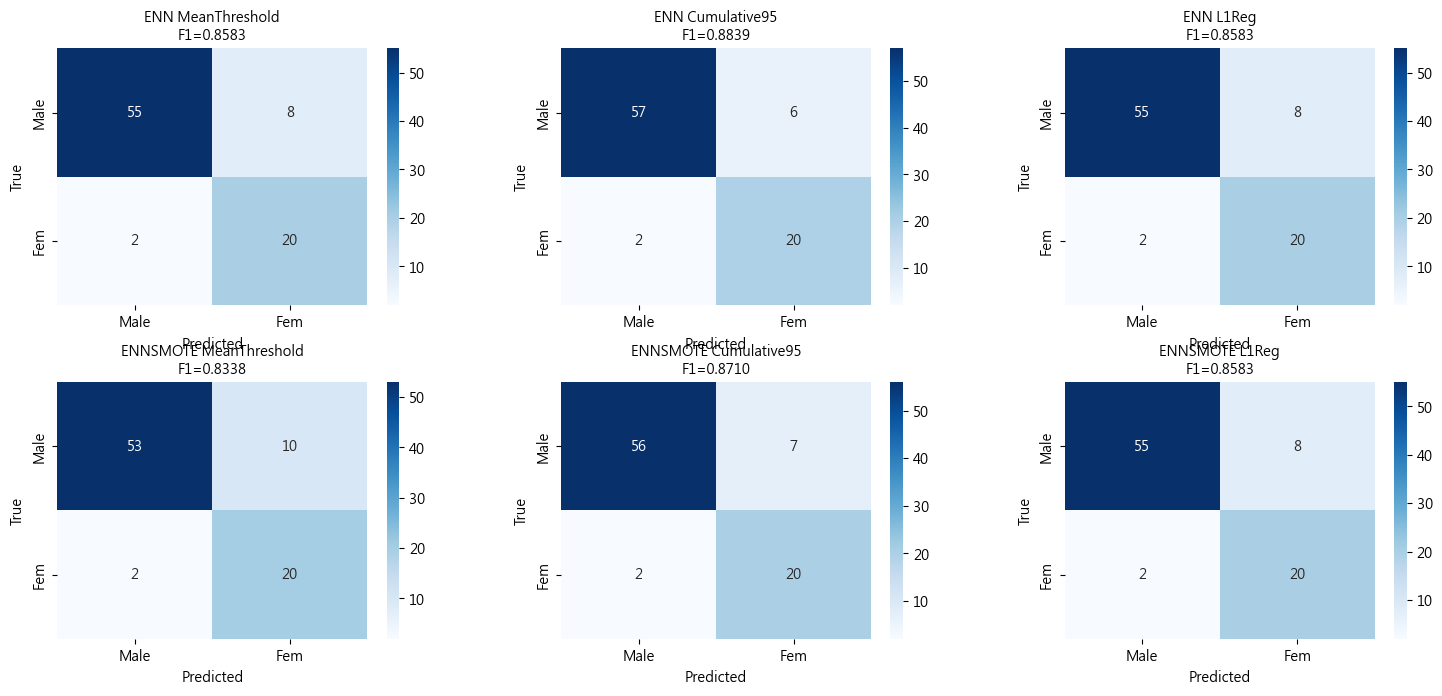

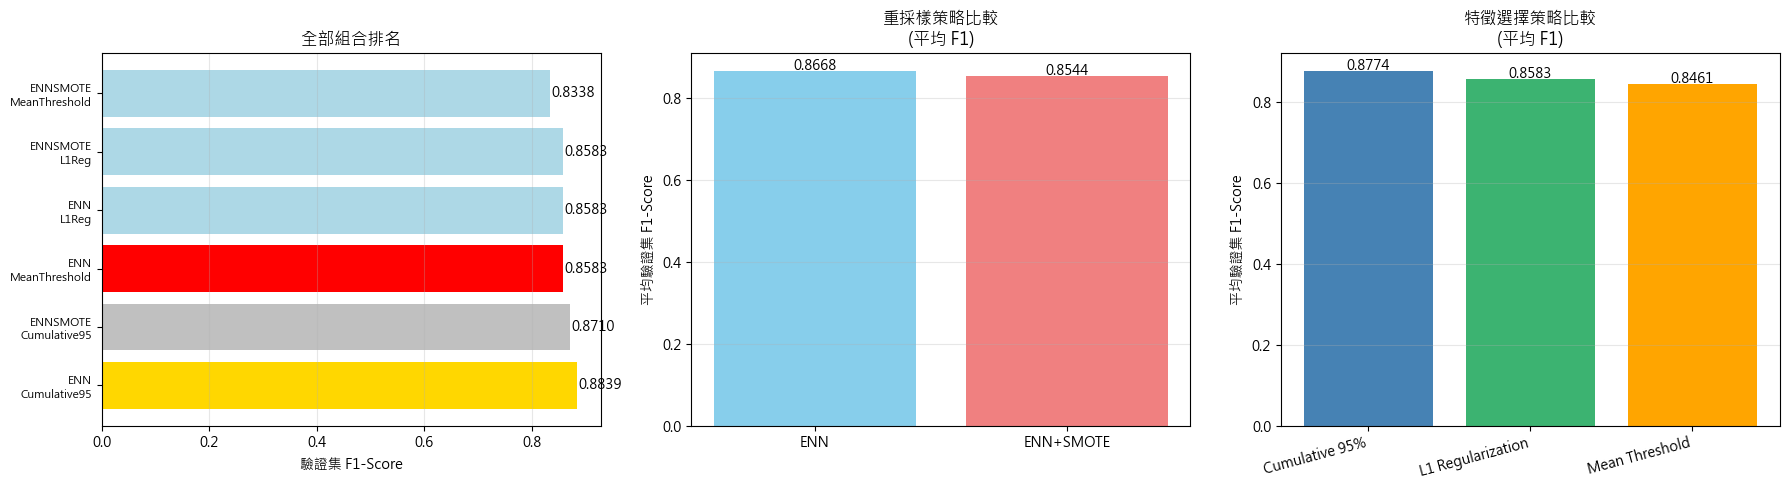

In [18]:
# 創建視覺化
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. 混淆矩陣 (2x3)
model_names = list(results.keys())
for i, name in enumerate(model_names):
    row = i // 3
    col = i % 3
    ax = fig.add_subplot(gs[row, col])
    
    cm = confusion_matrix(y_valid, results[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Male', 'Fem'],
                yticklabels=['Male', 'Fem'])
    
    title = name.replace('_', ' ')
    f1 = results[name]['valid_f1']
    ax.set_title(f'{title}\nF1={f1:.4f}', fontsize=10)
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

# 2. F1-Score 比較圖
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 2.1 總體排名
ax = axes[0]
bars = ax.barh(range(len(comparison_df)), comparison_df['驗證集 F1'], 
               color=['gold' if i == 0 else 'silver' if i == 1 else 'red' if i == 2 else 'lightblue' 
                      for i in range(len(comparison_df))])
ax.set_yticks(range(len(comparison_df)))
ax.set_yticklabels([name.replace('_', '\n') for name in comparison_df['組合名稱']], fontsize=8)
ax.set_xlabel('驗證集 F1-Score')
ax.set_title('全部組合排名')
ax.grid(axis='x', alpha=0.3)
for i, v in enumerate(comparison_df['驗證集 F1']):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center')

# 2.2 重採樣策略比較
ax = axes[1]
resampling_avg = comparison_df.groupby('重採樣策略')['驗證集 F1'].mean()
bars = ax.bar(range(len(resampling_avg)), resampling_avg.values, 
              color=['skyblue', 'lightcoral'])
ax.set_xticks(range(len(resampling_avg)))
ax.set_xticklabels(resampling_avg.index)
ax.set_ylabel('平均驗證集 F1-Score')
ax.set_title('重採樣策略比較\n(平均 F1)')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(resampling_avg.values):
    ax.text(i, v + 0.002, f'{v:.4f}', ha='center')

# 2.3 特徵選擇策略比較
ax = axes[2]
feature_avg = comparison_df.groupby('特徵選擇')['驗證集 F1'].mean()
bars = ax.bar(range(len(feature_avg)), feature_avg.values,
              color=['steelblue', 'mediumseagreen', 'orange'])
ax.set_xticks(range(len(feature_avg)))
ax.set_xticklabels(feature_avg.index, rotation=15, ha='right')
ax.set_ylabel('平均驗證集 F1-Score')
ax.set_title('特徵選擇策略比較\n(平均 F1)')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(feature_avg.values):
    ax.text(i, v + 0.002, f'{v:.4f}', ha='center')

plt.tight_layout()
plt.show()

## 📊 交互效應分析

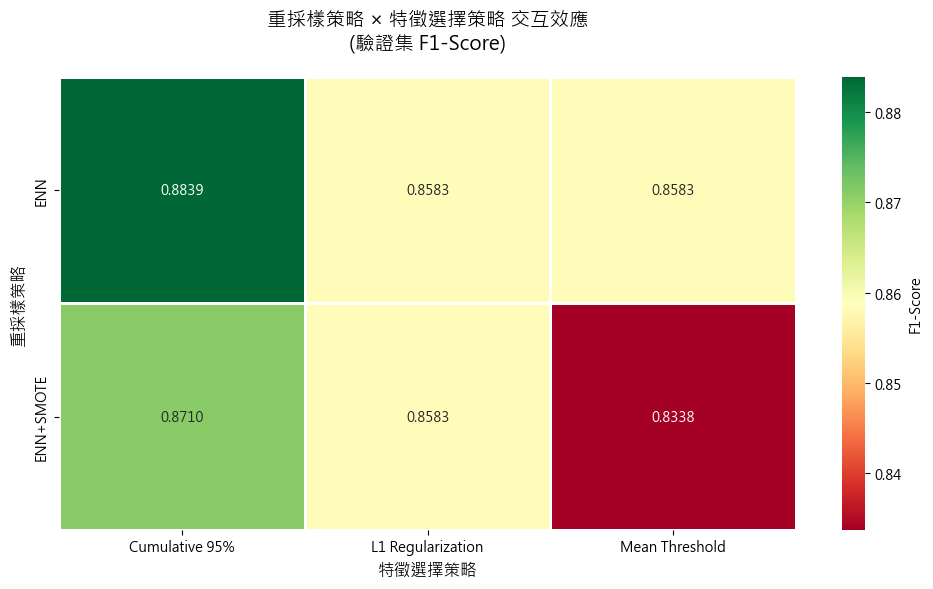


📊 交互效應分析：
特徵選擇       Cumulative 95%  L1 Regularization  Mean Threshold
重採樣策略                                                       
ENN              0.883880           0.858333        0.858333
ENN+SMOTE        0.870973           0.858333        0.833768

📈 主效應分析：

重採樣策略影響:
  ENN 平均 F1: 0.8668
  ENN+SMOTE 平均 F1: 0.8544
  差異: 0.0125

特徵選擇策略影響:
  Mean Threshold: 0.8461
  Cumulative 95%: 0.8774
  L1 Regularization: 0.8583


In [19]:
# 創建 Heatmap 顯示交互效應
pivot_table = comparison_df.pivot_table(
    values='驗證集 F1',
    index='重採樣策略',
    columns='特徵選擇'
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt='.4f', cmap='RdYlGn', 
            cbar_kws={'label': 'F1-Score'},
            linewidths=1, linecolor='white')
plt.title('重採樣策略 × 特徵選擇策略 交互效應\n(驗證集 F1-Score)', fontsize=14, pad=20)
plt.xlabel('特徵選擇策略', fontsize=12)
plt.ylabel('重採樣策略', fontsize=12)
plt.tight_layout()
plt.show()

print("\n📊 交互效應分析：")
print(pivot_table)

# 計算主效應
print("\n📈 主效應分析：")
print(f"\n重採樣策略影響:")
print(f"  ENN 平均 F1: {comparison_df[comparison_df['重採樣策略']=='ENN']['驗證集 F1'].mean():.4f}")
print(f"  ENN+SMOTE 平均 F1: {comparison_df[comparison_df['重採樣策略']=='ENN+SMOTE']['驗證集 F1'].mean():.4f}")
print(f"  差異: {abs(comparison_df[comparison_df['重採樣策略']=='ENN']['驗證集 F1'].mean() - comparison_df[comparison_df['重採樣策略']=='ENN+SMOTE']['驗證集 F1'].mean()):.4f}")

print(f"\n特徵選擇策略影響:")
for strategy in ['Mean Threshold', 'Cumulative 95%', 'L1 Regularization']:
    avg_f1 = comparison_df[comparison_df['特徵選擇']==strategy]['驗證集 F1'].mean()
    print(f"  {strategy}: {avg_f1:.4f}")

## 📤 產生 Kaggle Submission (使用最佳組合)

In [20]:
# 取得最佳模型
best_combo_name = comparison_df.iloc[0]['組合名稱']
best_result = results[best_combo_name]

# 預測測試集
X_test_sel = X_test_enc[best_result['features']]
test_pred = best_result['model'].predict(X_test_sel) + labels_offset

submission = pd.DataFrame({
    'id': test_ids if test_ids is not None else range(1, len(test_pred) + 1),
    'gender': test_pred
})

filename = f'submission_best_{best_combo_name}.csv'
submission.to_csv(filename, index=False)

print(f"✅ {filename} 儲存成功！")
print(f"\n預測分布:")
print(submission['gender'].value_counts())
print(f"\n前 10 筆:")
print(submission.head(10))

✅ submission_best_ENN_Cumulative95.csv 儲存成功！

預測分布:
gender
1    268
2    158
Name: count, dtype: int64

前 10 筆:
   id  gender
0   1       1
1   2       1
2   3       2
3   4       1
4   5       2
5   6       1
6   7       1
7   8       1
8   9       2
9  10       1


## 📊 實驗總結

In [21]:
print("="*70)
print("完整實驗總結")
print("="*70)

print("\n✅ 實驗設計：2×3 網格實驗")
print("   - 重採樣策略: ENN, ENN+SMOTE")
print("   - 特徵選擇: Mean Threshold, Cumulative 95%, L1 Regularization")
print(f"   - 總共訓練: {len(results)} 個模型組合")

print("\n🏆 最佳組合：")
print(f"   名稱: {best_combo_name}")
print(f"   重採樣: {best_combo['重採樣策略']}")
print(f"   特徵選擇: {best_combo['特徵選擇']}")
print(f"   特徵數: {best_combo['特徵數']}")
print(f"   CV F1: {best_combo['CV F1']:.4f}")
print(f"   驗證集 F1: {best_combo['驗證集 F1']:.4f}")

print("\n📈 關鍵發現：")
enn_avg = comparison_df[comparison_df['重採樣策略']=='ENN']['驗證集 F1'].mean()
enn_smote_avg = comparison_df[comparison_df['重採樣策略']=='ENN+SMOTE']['驗證集 F1'].mean()
if enn_smote_avg > enn_avg:
    print(f"   1. ENN+SMOTE 優於 ENN (平均提升 {(enn_smote_avg - enn_avg):.4f})")
else:
    print(f"   1. ENN 優於 ENN+SMOTE (平均提升 {(enn_avg - enn_smote_avg):.4f})")

best_feature_strategy = comparison_df.groupby('特徵選擇')['驗證集 F1'].mean().idxmax()
print(f"   2. 最佳特徵選擇策略: {best_feature_strategy}")

print(f"\n✅ Submission 已生成: {filename}")
print("="*70)

完整實驗總結

✅ 實驗設計：2×3 網格實驗
   - 重採樣策略: ENN, ENN+SMOTE
   - 特徵選擇: Mean Threshold, Cumulative 95%, L1 Regularization
   - 總共訓練: 6 個模型組合

🏆 最佳組合：
   名稱: ENN_Cumulative95
   重採樣: ENN
   特徵選擇: Cumulative 95%
   特徵數: 20
   CV F1: 0.9076
   驗證集 F1: 0.8839

📈 關鍵發現：
   1. ENN 優於 ENN+SMOTE (平均提升 0.0125)
   2. 最佳特徵選擇策略: Cumulative 95%

✅ Submission 已生成: submission_best_ENN_Cumulative95.csv
